**Clickstream SQL Project Data Exploration, Cleaning and Modeling**


Data Exploration and Cleaning of table events_raw (original dataset)


*   Checked for NULL values
*   Checked for inconsistent values

Example Queries:


In [ ]:
# Making sure that the NULLs in product_id are only on event_types that are not directly connected to a single product
SELECT DISTINCT event_type
FROM `clickstream-sql-project.clickstream.events`
WHERE product_id IS NULL

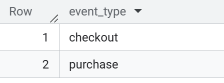

In [ ]:
# Making sure that the column quantity is only related to actual products being added to the cart
SELECT DISTINCT
event_type,
quantity
FROM `clickstream-sql-project.clickstream.events`
WHERE NOT event_type = 'add_to_cart'

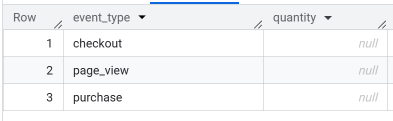

In [ ]:
# Making sure that cart size only relates to products being checked out
SELECT DISTINCT event_type,
cart_size
FROM `clickstream-sql-project.clickstream.events`
WHERE NOT event_type = 'checkout'

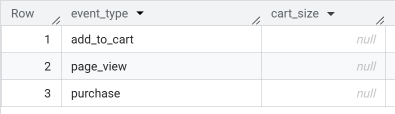

In [ ]:
# Any missing values in the Amount column?
SELECT amount
FROM `clickstream-sql-project.clickstream.events`
WHERE event_type = 'purchase'
AND amount IS NULL
# Query comes back empty, NULLs are actual nulls and not missing values

In [ ]:
# Are amounts only shown for purchases?
SELECT DISTINCT event_type
FROM `clickstream-sql-project.clickstream.events`
WHERE amount IS NOT NULL

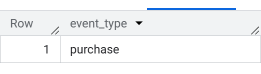

In [ ]:
# Checking if SessionID actually means the same session
SELECT user_id, session_id, DATE(timestamp)
FROM `clickstream-sql-project.clickstream.events`
ORDER BY user_id, session_id
LIMIT 50
# Looks good, this was actually an issue I ran into with a different data set

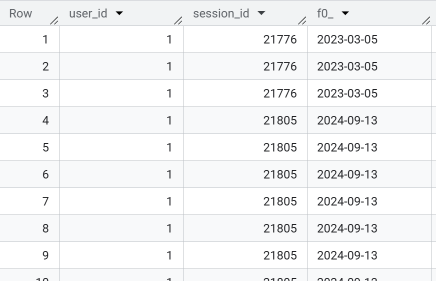

Based on Data Exploration there is no need for cleaning the data.





Data Modeling

When I started the project, I developed a project plan, that included the questions I want to answer with this project and the KPIs I want to check.
Based on that I created the schema for two more tables that I want to model from the original data set.



*   sessions
*   users





Table 'sessions'

Gives an overview over each sessions, grouping all events, allowing me to check on funnels, session lengths, and drop off points.

Columns:
*   session_id
*   user_id
*   total_events (within the session)
*   user_path (within the session)
*   outcome (did the user purchase anything during the session)
*   session_length (in minutes)
*   products_viewed (number of products viewed during the session)
*   products_added (number of products added to cart during the session)
*   products_checkout (number of products checked out during the session)
*   products_purchased (number of products purchased during the session)
*   last_event (last event before session ended)
*   amount_session (amount spent during the session)
*   first_timestamp (timestamp of first event in session)
*   last_timestamp (timestamp of last event in session)


Products_purchased required an extra update of the table. Calculating this within the original CREATE statement wasn't possible. The cart_size is only associated to checkout, but not every checkout leads to a purchase, sometimes the user drops off after checkout.

In [ ]:
CREATE TABLE `clickstream-sql-project.clickstream.sessions` AS
SELECT
  session_id,
  user_id,
  COUNT(event_type) AS total_events,
  STRING_AGG(event_type ORDER BY timestamp) AS user_path,
  CASE WHEN
    (MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)) = 1
  THEN 'purchase' ELSE 'no_purchase' END AS outcome,
  TIMESTAMP_DIFF(MAX(timestamp), MIN(timestamp), MINUTE) AS session_length,
  COUNT (CASE WHEN event_type = 'page_view' THEN  product_id END) AS products_viewed,
  CAST(SUM(CASE WHEN event_type = 'add_to_cart' THEN quantity END) AS INT64) AS products_added,
  CAST(SUM(CASE WHEN event_type = 'checkout' THEN cart_size END) AS INT64) AS products_checkout,
  ARRAY_AGG(event_type ORDER BY timestamp DESC LIMIT 1) AS last_event,
  SUM(amount) AS amount_session,
  MIN(timestamp) AS first_timestamp,
  MAX(timestamp) AS last_timestamp
FROM `clickstream-sql-project.clickstream.events`
GROUP BY
  session_id,
  user_id

The Big Query free version does not allow for DML statements, so instead of altering the table to add a column and then update the column, I have to run the CREATE statement again and add the column. I opted for adding the extra column "products_checkout" to make it easier.

In [ ]:
CREATE OR REPLACE TABLE `clickstream-sql-project.clickstream.sessions` AS
SELECT
  *,
  SUM(CASE WHEN outcome = 'purchase' THEN products_checkout ELSE NULL END) AS products_purchased
FROM `clickstream-sql-project.clickstream.sessions`
GROUP BY session_id, user_id, total_events, user_path, outcome, session_length,
         products_viewed, products_added, last_event, amount_session,
         first_timestamp, last_timestamp, products_checkout

To make sure that the table I created makes sense, I ran some sanity checks.
Examples:

In [ ]:
# Sessions per users (also ran without DESC to check that there is at least one session per user)
SELECT user_id, COUNT(session_id) AS sessions_per_user
FROM `clickstream-sql-project.clickstream.sessions`
GROUP BY user_id
ORDER BY sessions_per_user DESC
LIMIT 20

In [ ]:
# Session length seems plausible
SELECT
  MIN(session_length) AS min_length,
  MAX(session_length) AS max_length,
  AVG(session_length) AS avg_length
FROM `clickstream-sql-project.clickstream.sessions`

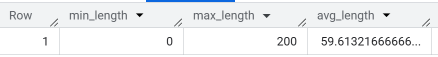

In [ ]:
# did aggregation work correctly? Ran with total_events ASC as well to check that I only get one event name
SELECT user_id, session_id, user_path
FROM `clickstream-sql-project.clickstream.sessions`
ORDER BY total_events DESC
LIMIT 20;

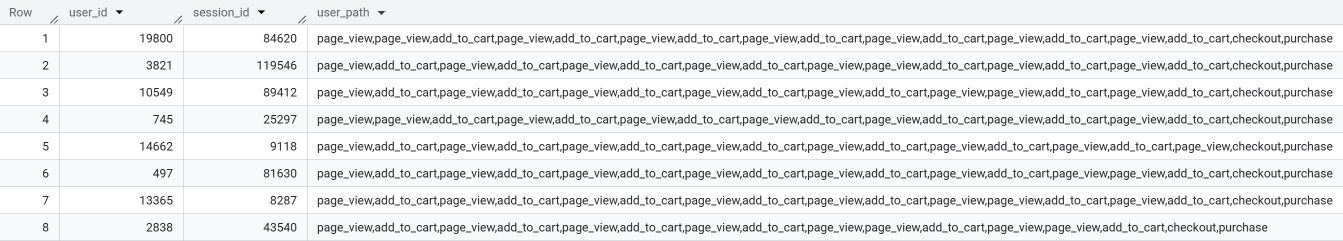

In [ ]:
# Check that outcome generated both types of outcome
SELECT outcome, COUNT(*) AS count
FROM `clickstream-sql-project.clickstream.sessions`
GROUP BY outcome

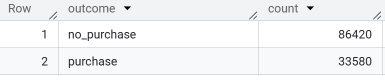

In [ ]:
# Check if outcome purchase automatically means last_event = purchase
SELECT
  outcome,
  last_event
FROM `clickstream-sql-project.clickstream.sessions`
GROUP BY outcome, last_event

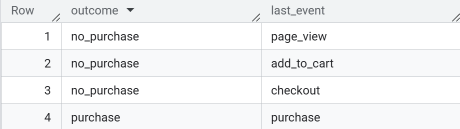

In [ ]:
# Did I add the column products_purchased correctly?
SELECT
  session_id,
  products_checkout,
  products_purchased
FROM `clickstream-sql-project.clickstream.sessions`
WHERE outcome = 'purchase'
ORDER BY products_checkout DESC
LIMIT 50

In [ ]:
# Result matches expectations from MAX(cart_size) query
SELECT MAX(cart_size)
FROM `clickstream-sql-project.clickstream.events`

Table 'users'

Gives an overview over each individual user, grouping all sessions, allowing me to check on metrics like user behavior, activity, and total purchases.

Columns:
*   user_id
*   total_session (by user)
*   first_seen (first activity by user)
*   last_seen (last activity by user)
*   total_time_spent (in minutes)
*   avg_time_spent (in minutes)
*   total_products_viewed (total of products viewed during single sessions)
*   total_products_added (total of products added to cart during single sessions)
*   total_products_checkout (total of products checked out during single sessions)
*   total_products_purchased
*   amount_user (total amount spent by user)
*   conversion_rate (percentage of sessions with a purchase)


In [ ]:
CREATE TABLE `clickstream-sql-project.clickstream.users` AS
SELECT
  user_id,
  COUNT(session_id) AS total_sessions,
  MIN(first_timestamp) AS first_seen,
  MAX(last_timestamp) AS last_seen,
  SUM(session_length) AS total_time_spent,
  AVG(session_length) AS avg_time_spent,
  SUM(products_viewed) AS total_products_viewed,
  SUM(products_added) AS total_products_added,
  SUM(products_checkout) AS total_products_checkout,
  SUM(products_purchased) AS total_products_purchased,
  SUM(amount_session) AS amount_user,
  ROUND(COUNT(CASE WHEN outcome='purchase' THEN session_id END) / COUNT(session_id) *100,2)AS conversion_rate
FROM `clickstream-sql-project.clickstream.sessions`
GROUP BY user_id

Some examples for my sanity check for table 'users'

In [ ]:
# Number of users
SELECT COUNT(*) AS total_users
FROM `clickstream-sql-project.clickstream.users`

# Output matches the unique users in the tables events and sessions
SELECT COUNT(DISTINCT user_id) AS total_users
FROM `clickstream-sql-project.clickstream.events`

SELECT COUNT(DISTINCT user_id) AS total_users
FROM `clickstream-sql-project.clickstream.sessions`

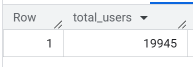

In [ ]:
# Number of sessions per users, also ran with ASC. Looks plausible and matched the sanity check from the sessions table
SELECT
  user_id,
  total_sessions
FROM `clickstream-sql-project.clickstream.users`
ORDER BY total_sessions DESC
LIMIT 10

In [ ]:
# Making sure there are no negative counts, impossibly high counts, counts get less with every step etc.
# All looks reasonable
SELECT
  MIN(total_products_viewed) AS min_viewed,
  MAX(total_products_viewed) AS max_viewed,
  MIN(total_products_added) AS min_added,
  MAX(total_products_added) AS max_added,
  MIN(total_products_checkout) AS min_checkout,
  MAX(total_products_checkout) AS max_checkout,
  MIN(total_products_purchased) AS min_purchased,
  MAX(total_products_purchased) AS max_purchased
FROM `clickstream-sql-project.clickstream.users`

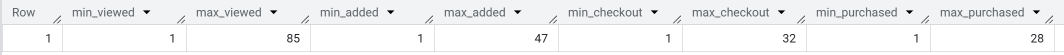

In [ ]:
# Check if the conversion rate makes sense
SELECT
  MIN(conversion_rate) AS min_conversion,
  MAX(conversion_rate) AS max_conversion,
  ROUND(AVG(conversion_rate),2) AS avg_conversion
FROM `clickstream-sql-project.clickstream.users`

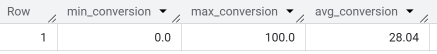

In [ ]:
# check on the timestamps, to make sure they include all user activities
SELECT
  user_id,
  MIN(first_seen) AS first_seen_overall,
  MAX(last_seen) AS last_seen_overall
FROM `clickstream-sql-project.clickstream.users`
GROUP BY user_id
LIMIT 20
# something seems to be odd, it looks like the users were only active on one day

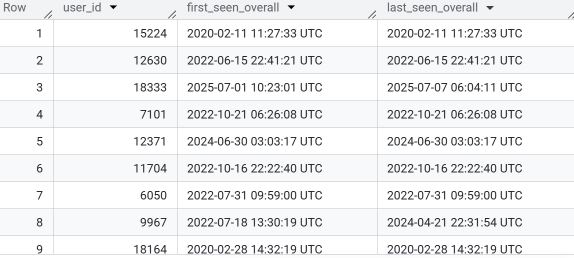

In [ ]:
# might be because the first 20 rows are all single session users
# checking the same with users with the most sessions
SELECT
  user_id,
  MIN(first_seen) AS first_seen_overall,
  MAX(last_seen) AS last_seen_overall,
  total_sessions
FROM `clickstream-sql-project.clickstream.users`
GROUP BY user_id, total_sessions
ORDER BY total_sessions DESC
LIMIT 20
# Output looks as expected now

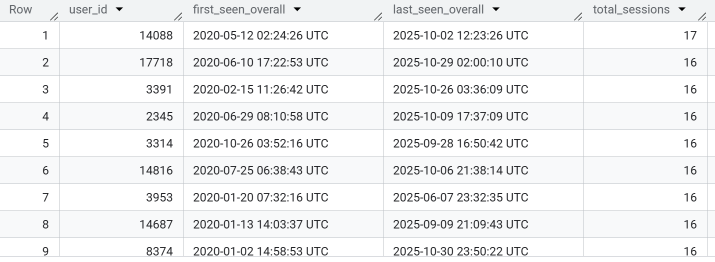

In [ ]:
# Checking that users that didn't buy any products have a conversion rate of zero
SELECT
  user_id,
  total_products_purchased,
  total_sessions,
  conversion_rate
FROM `clickstream-sql-project.clickstream.users`
WHERE total_products_purchased = 0
ORDER BY total_sessions DESC
LIMIT 20


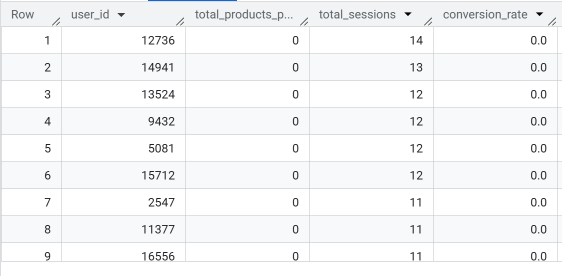